In [223]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns


from dtw import dtw
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [224]:
def load_audio_segments(base_path):
    """
    Загружает аудио сегменты из папок в структурированный формат
    """
    data = []
    
    # Проходим по всем папкам
    for folder_name in os.listdir(base_path):
        folder_path = os.path.join(base_path, folder_name)
        
        if os.path.isdir(folder_path):
            print(f"Загружаем файлы из папки: {folder_name}")
            
            # Проходим по всем файлам в папке
            for file_name in sorted(os.listdir(folder_path)):
                if file_name.startswith(folder_name) and file_name.endswith('.wav'):
                    file_path = os.path.join(folder_path, file_name)
                    
                    try:
                        # Загружаем аудиофайл
                        audio, sr = librosa.load(file_path, sr=22050)
                        
                        # Извлекаем номер сегмента из имени файла
                        segment_num = int(file_name.split('_')[-1].split('.')[0])
                        
                        data.append({
                            'audio': audio,
                            'sampling_rate': sr,
                            'label': folder_name,
                            'segment_number': segment_num,
                            'duration': len(audio) / sr
                        })
                        
                    except Exception as e:
                        print(f"Ошибка при загрузке {file_path}: {e}")
    
    # Создаем DataFrame
    df = pd.DataFrame(data)
    return df

base_path = "SOUNDS/"
audio_df = load_audio_segments(base_path)

print(f"Загружено {len(audio_df)} файлов")
print("Уникальные классы:", audio_df['label'].unique())
print(audio_df.head())

Загружаем файлы из папки: distributivi
Загружаем файлы из папки: dokumenti
Загружаем файлы из папки: filmi
Загружаем файлы из папки: fotografii
Загружаем файлы из папки: igri
Загружаем файлы из папки: knigi
Загружаем файлы из папки: musika
Загружаем файлы из папки: proekti
Загружаем файлы из папки: zagruzki
Загружено 135 файлов
Уникальные классы: ['distributivi' 'dokumenti' 'filmi' 'fotografii' 'igri' 'knigi' 'musika'
 'proekti' 'zagruzki']
                                               audio  sampling_rate  \
0  [0.0008544922, 0.009460449, 0.012878418, 0.006...          22050   
1  [-0.00015258789, -0.00061035156, -0.0011901855...          22050   
2  [-0.019927979, -0.01473999, -0.011810303, -0.0...          22050   
3  [0.006591797, 0.007385254, 0.0078125, 0.008239...          22050   
4  [-9.1552734e-05, -9.1552734e-05, -3.0517578e-0...          22050   

          label  segment_number  duration  
0  distributivi               1  1.047664  
1  distributivi               2  1.24222

In [225]:
audio_df['label'].value_counts()

label
distributivi    15
dokumenti       15
filmi           15
fotografii      15
igri            15
knigi           15
musika          15
proekti         15
zagruzki        15
Name: count, dtype: int64

In [304]:
def extract_mfcc_features(audio_df, n_mfcc=13, frame_length=2048, hop_length=512, window='hamming', overlap_percentage=None):
    """
    Извлекает MFCC признаки из аудио сегментов
    """
    
    mfcc_features = []
    
    for idx, row in audio_df.iterrows():
        audio = row['audio']
        sr = row['sampling_rate']
        if overlap_percentage:
            hop_length = int(frame_length * (1 - overlap_percentage / 100.0))
        # Извлекаем MFCC признаки
        mfcc = librosa.feature.mfcc(
            y=audio, 
            sr=sr, 
            n_mfcc=n_mfcc,
            n_fft=frame_length,
            hop_length=hop_length,
            window=window,
        )
        mfcc = mfcc.ravel(order="F")
        
        mfcc_features.append({
            'label': row['label'],
            'segment_number': row['segment_number'],
            'mfcc_matrix': mfcc,
        })
        
    return pd.DataFrame(mfcc_features)

# Использование функции
print("Извлечение MFCC признаков...")
mfcc_features_df = extract_mfcc_features(audio_df, n_mfcc=13, overlap_percentage=0.3)

Извлечение MFCC признаков...


In [305]:
print("\nПервые 5 записей:")
mfcc_features_df.iloc[0:100]


Первые 5 записей:


,label,segment_number,mfcc_matrix
0,distributivi,1,"[-395.13977, 99.69699, -1.624866, 95.67745, -1..."
1,distributivi,2,"[-516.8202, 184.04393, 42.37462, 33.84675, 23...."
2,distributivi,3,"[-349.38477, 76.51675, 16.154343, 77.06534, -4..."
3,distributivi,4,"[-490.44232, 149.61198, 43.15097, 43.46119, 26..."
4,distributivi,5,"[-516.8662, 155.75528, 38.730774, 31.885918, 2..."
...,...,...,...
95,musika,6,"[-418.96146, 157.80923, 8.118353, 5.477879, 7...."
96,musika,7,"[-430.21802, 166.32562, 7.730879, 10.814884, -..."
97,musika,8,"[-369.7812, 144.10567, 11.80504, 19.169146, 16..."
98,musika,9,"[-405.8334, 158.60886, -9.277081, 22.051199, 1..."


In [228]:
def compare_mfcc(mfcc1, mfcc2, title = 'Сравнение двух слов'):
    t0 = np.linspace(0, 100, 100) 
    t1 = np.linspace(0, 100, 100)
    plt.figure(figsize=(14, 5))
    offset = 1.5


    plt.plot(t0, mfcc1[:100],color="blue", label='Первое слово')
    plt.plot(t1, mfcc2[:100],color="red", label='Второе слово')
    plt.title(title)
    plt.xlabel('Кадр')
    plt.ylabel('mfcc')
    plt.legend()
    plt.grid(True)

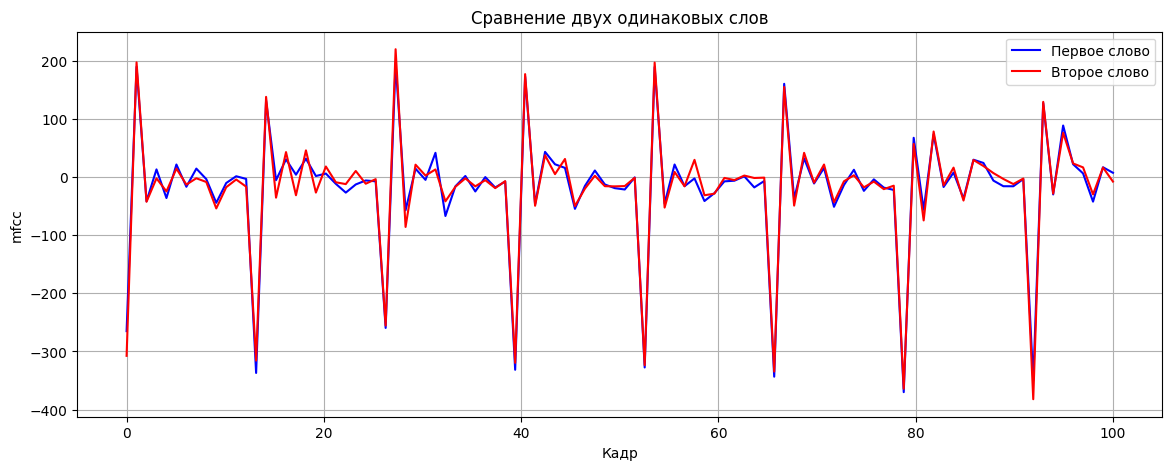

In [299]:
compare_mfcc(mfcc_features_df['mfcc_matrix'][52], mfcc_features_df['mfcc_matrix'][53], title = 'Сравнение двух одинаковых слов')

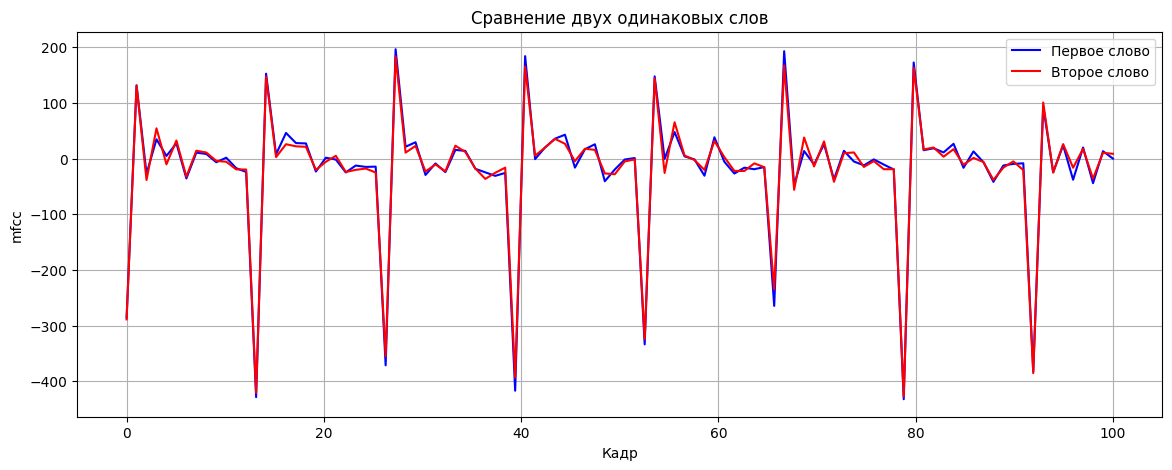

In [293]:
compare_mfcc(mfcc_features_df['mfcc_matrix'][27], mfcc_features_df['mfcc_matrix'][28], title = 'Сравнение двух одинаковых слов')

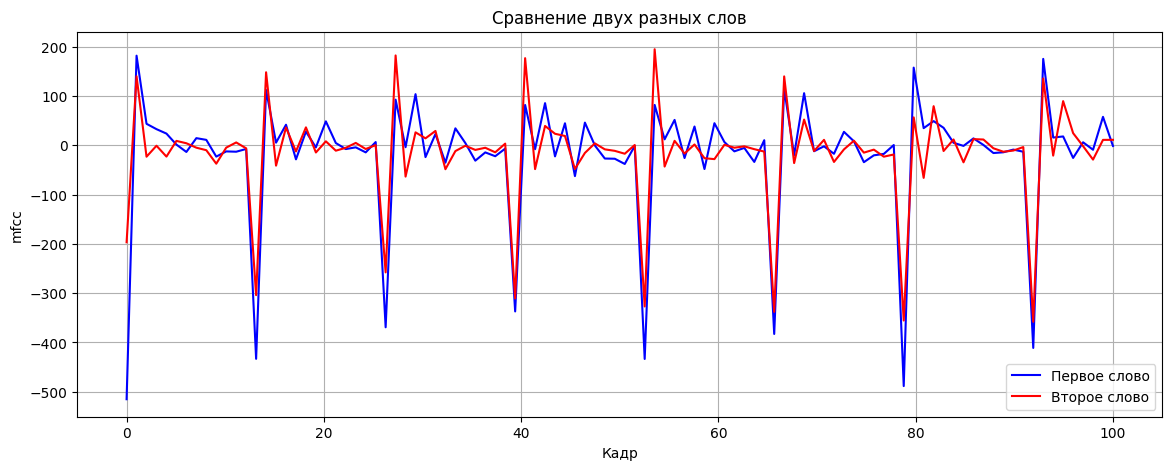

In [295]:
compare_mfcc(mfcc_features_df['mfcc_matrix'][1], mfcc_features_df['mfcc_matrix'][50], title = 'Сравнение двух разных слов')

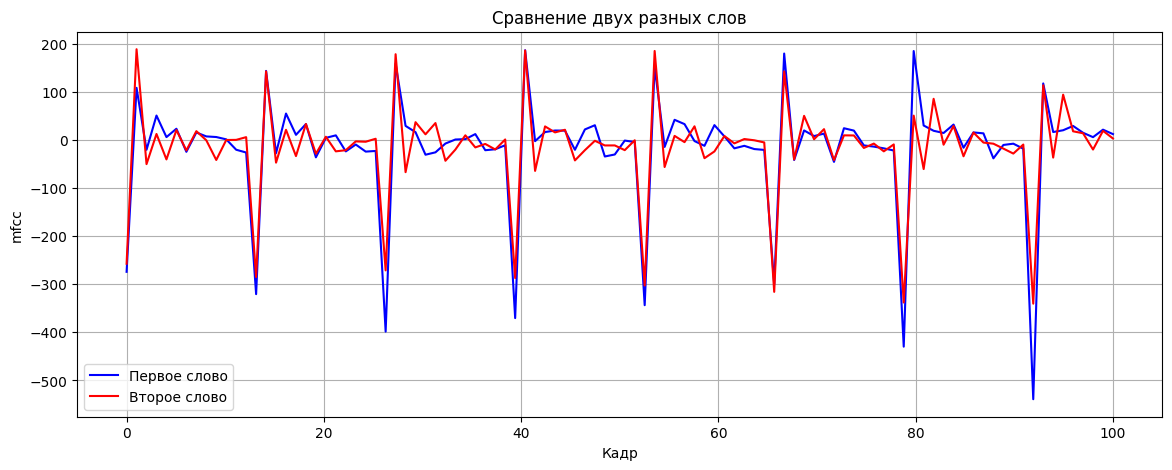

In [296]:
compare_mfcc(mfcc_features_df['mfcc_matrix'][20], mfcc_features_df['mfcc_matrix'][58], title = 'Сравнение двух разных слов')

In [233]:
def split_dataset(mfcc_features_df, random_state=42):
    """
    Разбивает данные на обучающую и тестовую выборки
    """
    # Проверяем, что у нас есть 15 сегментов
    unique_segments = mfcc_features_df['segment_number'].unique().tolist()
    print(f"Уникальные номера сегментов: {sorted(unique_segments)}")
    print(f"Всего сегментов: {len(unique_segments)}")
    
    # Группируем по меткам (классам)
    unique_labels = mfcc_features_df['label'].unique().tolist()
    print(f"Уникальные классы: {unique_labels}")
    
    # Создаем списки для train и test
    train_indices = []
    test_indices = []
    
    # Для каждого класса выбираем тестовые сегменты
    for label in unique_labels:
        label_data = mfcc_features_df[mfcc_features_df['label'] == label]
        
        # Получаем все сегменты для этого класса
        segments = sorted(label_data['segment_number'].unique().tolist())
        print(f"Класс {label}: сегменты {segments}")
        
        # Выбираем тестовые сегменты (примерно 20% от 15 = 3 сегмента)
        test_segments = sorted(np.random.choice(segments, size=3, replace=False).tolist())
        train_segments = [s for s in segments if s not in test_segments]
        
        print(f"  Train сегменты: {train_segments}")
        print(f"  Test сегменты: {test_segments}")
        
        # Добавляем индексы в соответствующие списки
        train_indices.extend(label_data[label_data['segment_number'].isin(train_segments)].index.tolist())
        test_indices.extend(label_data[label_data['segment_number'].isin(test_segments)].index.tolist())
    
    # Создаем train и test DataFrame
    train_df = mfcc_features_df.loc[train_indices].reset_index(drop=True)
    test_df = mfcc_features_df.loc[test_indices].reset_index(drop=True)
    
    return train_df, test_df

In [234]:
print("Разбиваем данные на обучающую и тестовую выборки...")
train_df, test_df = split_dataset(mfcc_features_df)

print(f"\nРазмер обучающей выборки: {len(train_df)}")
print(f"Размер тестовой выборки: {len(test_df)}")
print(f"Соотношение train/test: {len(train_df)/len(mfcc_features_df):.2f}/{len(test_df)/len(mfcc_features_df):.2f}")

# Проверяем распределение классов в обеих выборках
print("\nРаспределение классов в обучающей выборке:")
print(train_df['label'].value_counts())

print("\nРаспределение классов в тестовой выборке:")
print(test_df['label'].value_counts())

Разбиваем данные на обучающую и тестовую выборки...
Уникальные номера сегментов: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Всего сегментов: 15
Уникальные классы: ['distributivi', 'dokumenti', 'filmi', 'fotografii', 'igri', 'knigi', 'musika', 'proekti', 'zagruzki']
Класс distributivi: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [2, 3, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15]
  Test сегменты: [1, 4, 11]
Класс dokumenti: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 3, 4, 5, 6, 7, 8, 10, 11, 12, 14, 15]
  Test сегменты: [2, 9, 13]
Класс filmi: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 14, 15]
  Test сегменты: [1, 6, 13]
Класс fotografii: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
  Test сегменты: [3, 4, 15]
Класс igri: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 

In [235]:
train_df.iloc[:15]

,label,segment_number,mfcc_matrix
0,distributivi,2,"[-511.61005, 177.5007, 46.91677, 31.414116, 24..."
1,distributivi,3,"[-349.38477, 76.51674, 16.154343, 77.06534, -4..."
2,distributivi,5,"[-516.7122, 155.54791, 38.90867, 31.751595, 20..."
3,distributivi,6,"[-335.98538, 72.915115, -0.13044518, 87.12496,..."
4,distributivi,7,"[-345.5397, 58.07206, 4.791378, 84.51776, -8.1..."
5,distributivi,8,"[-332.85602, 65.460495, 0.99569196, 88.50781, ..."
6,distributivi,9,"[-390.467, 84.11316, 23.274466, 71.853134, -1...."
7,distributivi,10,"[-497.99725, 152.06288, 54.09513, 41.087135, 2..."
8,distributivi,12,"[-360.68134, 115.43677, 24.949188, 22.47157, 1..."
9,distributivi,13,"[-339.1684, 68.75638, -10.2966, 95.36408, -10...."


In [236]:
X_train = train_df['mfcc_matrix'].values
y_train = train_df['label'].values

X_test = test_df['mfcc_matrix'].values
y_test = test_df['label'].values

print(f"Обучающая выборка: {len(X_train)} примеров")
print(f"Тестовая выборка: {len(X_test)} примеров")

Обучающая выборка: 108 примеров
Тестовая выборка: 27 примеров


In [237]:
import time
from dtw import dtw as dtw_func
def dtw_distance(mfcc1, mfcc2):
    return dtw_func(mfcc1, mfcc2, dist_method='euclidean').distance

def dtw_knn_predict(X_train, y_train, X_test, k=1):
    start = time.time()
    y_pred = []
    for i, test_mfcc in enumerate(X_test):
        if i % 5 == 0 or i == len(X_test) - 1:
            print(f"Прогресс: {i+1}/{len(X_test)} ({(i+1)/len(X_test)*100:.2f}%)")
        distances = []
        for train_mfcc, label in zip(X_train, y_train):
            distances.append((label, dtw_distance(test_mfcc, train_mfcc)))
        distances.sort(key=lambda x: x[1])
        labels = [label for label, _ in distances[:k]]
        y_pred.append(max(set(labels), key=labels.count))
    end = time.time()
    print(f"Время выполнения: {end-start:.4f} секунд")
    return y_pred
    

In [238]:
dtw_distance(X_train[0], X_train[1])

np.float64(17921.728939831257)

Прогресс: 1/27 (3.70%)
Прогресс: 6/27 (22.22%)
Прогресс: 11/27 (40.74%)
Прогресс: 16/27 (59.26%)
Прогресс: 21/27 (77.78%)
Прогресс: 26/27 (96.30%)
Прогресс: 27/27 (100.00%)
Время выполнения: 12.6804 секунд

Точность DTW (1-NN): 1.0000 (100.00%)

Отчёт по классификации:
              precision    recall  f1-score   support

distributivi       1.00      1.00      1.00         3
   dokumenti       1.00      1.00      1.00         3
       filmi       1.00      1.00      1.00         3
  fotografii       1.00      1.00      1.00         3
        igri       1.00      1.00      1.00         3
       knigi       1.00      1.00      1.00         3
      musika       1.00      1.00      1.00         3
     proekti       1.00      1.00      1.00         3
    zagruzki       1.00      1.00      1.00         3

    accuracy                           1.00        27
   macro avg       1.00      1.00      1.00        27
weighted avg       1.00      1.00      1.00        27



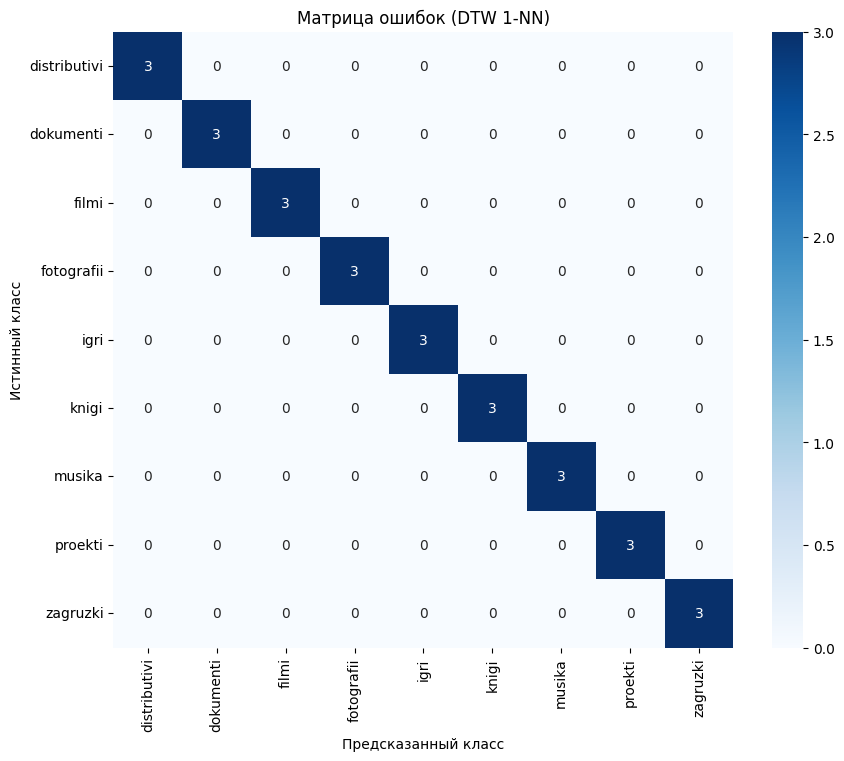

In [239]:
y_pred = dtw_knn_predict(X_train, y_train, X_test, k=3)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nТочность DTW (1-NN): {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\nОтчёт по классификации:")
print(classification_report(y_test, y_pred))

# --- Матрица ошибок ---
cm = confusion_matrix(y_test, y_pred, labels=sorted(np.unique(y_train)))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(np.unique(y_train)),
            yticklabels=sorted(np.unique(y_train)))
plt.title('Матрица ошибок (DTW 1-NN)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()

In [240]:
def norm_X(X, k):
    new_X = []
    for row in X:
        new_row = np.zeros(k)
        for i, item in enumerate(row):
            new_row[i % k] = new_row[i % k] + item / (len(row) / k)
        new_X.append(new_row)
    return new_X

In [241]:
from sklearn.preprocessing import StandardScaler
X_train_N = norm_X(X_train, 13)
X_test_N = norm_X(X_test, 13)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_N)
X_test_scaled = scaler.transform(X_test_N)


In [242]:
from sklearn.preprocessing import OneHotEncoder

# Создаём и настраиваем OneHotEncoder
encoder = OneHotEncoder(
    sparse_output=False,  # возвращаем плотный массив (не sparse matrix)
    categories='auto'       # автоматически определит категории из данных
)

# Применяем кодирование
y_train_encoded = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_encoded = encoder.fit_transform(y_test.reshape(-1, 1))
print(y_train_encoded.shape)
print(y_test_encoded.shape)


(108, 9)
(27, 9)


In [243]:
print("X_train_N shape:", X_train_scaled.shape)
print("y_train_encoded shape:", y_train_encoded.shape)

print("X_test_N shape:", X_test_scaled.shape)
print("y_test_encoded shape:", y_test_encoded.shape)

X_train_N shape: (108, 13)
y_train_encoded shape: (108, 9)
X_test_N shape: (27, 13)
y_test_encoded shape: (27, 9)


In [244]:
from keras import layers, models
from keras.optimizers import Adam

model = models.Sequential()

model.add(layers.Dense(64, activation='relu', input_shape=(13,)))
model.add(layers.Dense(39, activation='relu'))
model.add(layers.Dense(20, activation='relu'))
model.add(layers.Dense(9, activation='softmax'))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [245]:
history = model.fit(
    X_train_scaled,             
    y_train_encoded,         
    epochs=15,             
    batch_size=16,           
    validation_split=0.2,    
    verbose=0,
    shuffle=True        
)

# Извлекаем значения потерь и точности
# train_loss = history.history['loss']
# val_loss = history.history['val_loss']
# train_acc = history.history['accuracy']
# val_acc = history.history['val_accuracy']

# epochs = range(1, len(train_loss) + 1)

# plt.figure(figsize=(12, 5))

# # График потерь
# plt.subplot(1, 2, 1)
# plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
# plt.plot(epochs, val_loss, 'r--', label='Validation Loss')
# plt.title('Training and Validation Loss')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.legend()
# plt.grid(True)

# # График точности
# plt.subplot(1, 2, 2)
# plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
# plt.plot(epochs, val_acc, 'r--', label='Validation Accuracy')
# plt.title('Training and Validation Accuracy')
# plt.xlabel('Epochs')
# plt.ylabel('Accuracy')
# plt.legend()
# plt.grid(True)

# plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Время выполнения: 0.0663 секунд

Точность нейронной сети: 0.7407 (74.07%)

Отчёт по классификации:
              precision    recall  f1-score   support

           0       0.60      1.00      0.75         3
           1       0.43      1.00      0.60         3
           2       1.00      1.00      1.00         3
           3       1.00      0.67      0.80         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           6       0.75      1.00      0.86         3
           7       0.00      0.00      0.00         3
           8       0.00      0.00      0.00         3

    accuracy                           0.74        27
   macro avg       0.64      0.74      0.67        27
weighted avg       0.64      0.74      0.67        27



c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

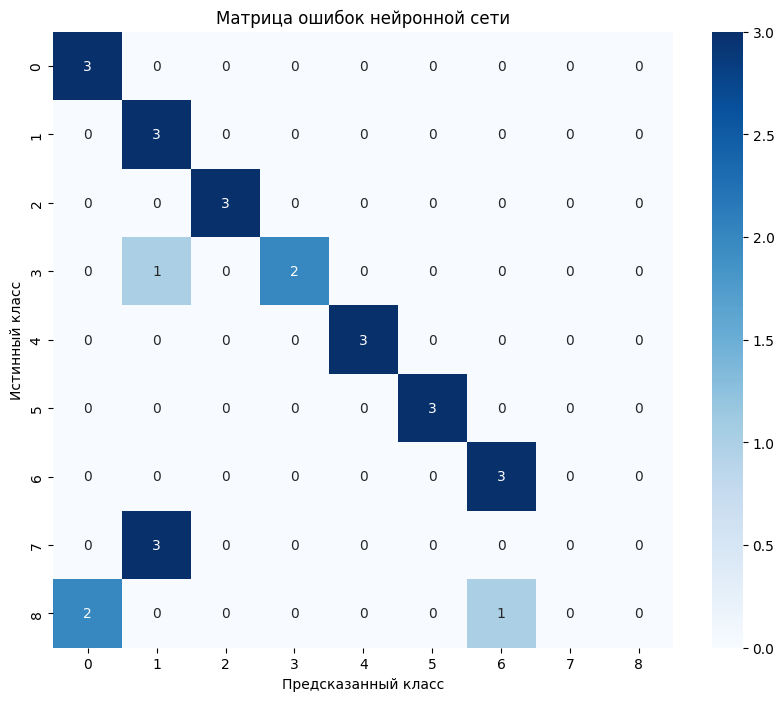

In [246]:
start = time.time()
y_pred_2 = model.predict(X_test_scaled)
end = time.time()
print(f"Время выполнения: {end-start:.4f} секунд")
y_pred_2 = np.argmax(y_pred_2, axis=1)

y_test_argmax = np.argmax(y_test_encoded, axis=1)

accuracy = accuracy_score(y_test_argmax, y_pred_2)
print(f"\nТочность нейронной сети: {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\nОтчёт по классификации:")
print(classification_report(y_test_argmax, y_pred_2))

# --- Матрица ошибок ---
cm = confusion_matrix(y_test_argmax, y_pred_2, labels=sorted(np.unique(y_test_argmax)))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(np.unique(y_test_argmax)),
            yticklabels=sorted(np.unique(y_test_argmax)))
plt.title('Матрица ошибок нейронной сети')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()


<h2>Сравнение при разных параметрах обучения</h2>

<h3>Количество информативных признаков</h3>

In [306]:
def train_by_param(audio_df ,n_mfcc = 13, overlap_percentage=None, window='hamming'):
    mfcc_features_df = extract_mfcc_features(audio_df, n_mfcc, overlap_percentage=overlap_percentage, window=window)
    train_df, test_df = split_dataset(mfcc_features_df)

    #DTW
    X_train = train_df['mfcc_matrix'].values
    y_train = train_df['label'].values

    X_test = test_df['mfcc_matrix'].values
    y_test = test_df['label'].values

    y_pred = dtw_knn_predict(X_train, y_train, X_test, k=3)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nТочность DTW (1-NN): {accuracy:.4f} ({accuracy*100:.2f}%)")

    print("\nОтчёт по классификации:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred, labels=sorted(np.unique(y_train)))
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=sorted(np.unique(y_train)),
                yticklabels=sorted(np.unique(y_train)))
    plt.title('Матрица ошибок (DTW 1-NN)')
    plt.ylabel('Истинный класс')
    plt.xlabel('Предсказанный класс')
    plt.show()

    #NNW
    X_train_N = norm_X(X_train, n_mfcc)
    X_test_N = norm_X(X_test, n_mfcc)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_N)
    X_test_scaled = scaler.transform(X_test_N)
    encoder = OneHotEncoder(
        sparse_output=False,
        categories='auto'
    )

    # Применяем кодирование
    y_train_encoded = encoder.fit_transform(y_train.reshape(-1, 1))
    y_test_encoded = encoder.fit_transform(y_test.reshape(-1, 1))
    model = models.Sequential()

    model.add(layers.Dense(64, activation='relu', input_shape=(n_mfcc,)))
    model.add(layers.Dense(39, activation='relu'))
    model.add(layers.Dense(20, activation='relu'))
    model.add(layers.Dense(9, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
    X_train_scaled,             
    y_train_encoded,         
    epochs=15,             
    batch_size=16,           
    validation_split=0.2,    
    verbose=1,
    shuffle=True        
)

    start = time.time()
    y_pred_2 = model.predict(X_test_scaled)
    end = time.time()
    print(f"Время выполнения: {end-start:.4f} секунд")
    y_pred_2 = np.argmax(y_pred_2, axis=1)

    y_test_argmax = np.argmax(y_test_encoded, axis=1)

    accuracy = accuracy_score(y_test_argmax, y_pred_2)
    print(f"\nТочность нейронной сети: {accuracy:.4f} ({accuracy*100:.2f}%)")

    print("\nОтчёт по классификации:")
    print(classification_report(y_test_argmax, y_pred_2))

    # --- Матрица ошибок ---
    cm = confusion_matrix(y_test_argmax, y_pred_2, labels=sorted(np.unique(y_test_argmax)))
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=sorted(np.unique(y_test_argmax)),
                yticklabels=sorted(np.unique(y_test_argmax)))
    plt.title('Матрица ошибок нейронной сети')
    plt.ylabel('Истинный класс')
    plt.xlabel('Предсказанный класс')
    plt.show()

Уникальные номера сегментов: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Всего сегментов: 15
Уникальные классы: ['distributivi', 'dokumenti', 'filmi', 'fotografii', 'igri', 'knigi', 'musika', 'proekti', 'zagruzki']
Класс distributivi: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 3, 5, 6, 7, 10, 11, 12, 13, 14, 15]
  Test сегменты: [4, 8, 9]
Класс dokumenti: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14]
  Test сегменты: [1, 10, 15]
Класс filmi: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 3, 4, 6, 7, 8, 9, 10, 12, 13, 14, 15]
  Test сегменты: [2, 5, 11]
Класс fotografii: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 3, 4, 5, 6, 7, 8, 11, 12, 14, 15]
  Test сегменты: [9, 10, 13]
Класс igri: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [3, 4, 5, 6, 7, 8, 9, 

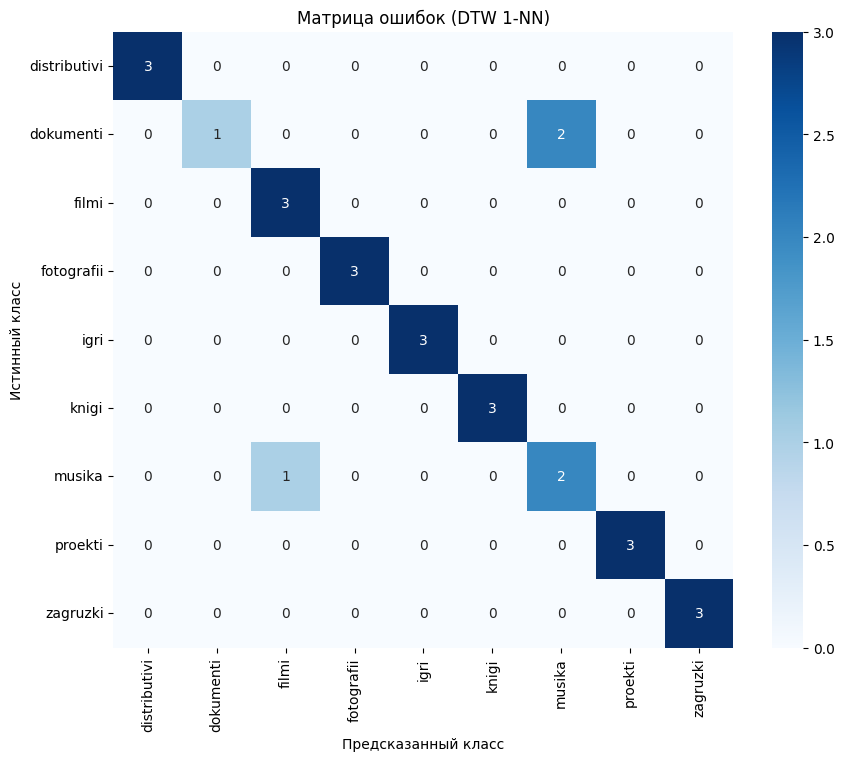

Epoch 1/15


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.1533 - loss: 2.1842 - val_accuracy: 0.0000e+00 - val_loss: 2.1997
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1435 - loss: 2.0880 - val_accuracy: 0.0000e+00 - val_loss: 2.2708
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1540 - loss: 1.9989 - val_accuracy: 0.0000e+00 - val_loss: 2.3487
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2915 - loss: 1.8786 - val_accuracy: 0.0000e+00 - val_loss: 2.4241
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3810 - loss: 1.8093 - val_accuracy: 0.0000e+00 - val_loss: 2.5171
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4345 - loss: 1.7128 - val_accuracy: 0.0000e+00 - val_loss: 2.6377
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5095 - loss: 1.6896 - val_accuracy: 0.0000e+00 - val_loss: 2.7867
Epoch 8/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6449 - loss: 1.5090 - val_accuracy: 0.0000e+00 - val

c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

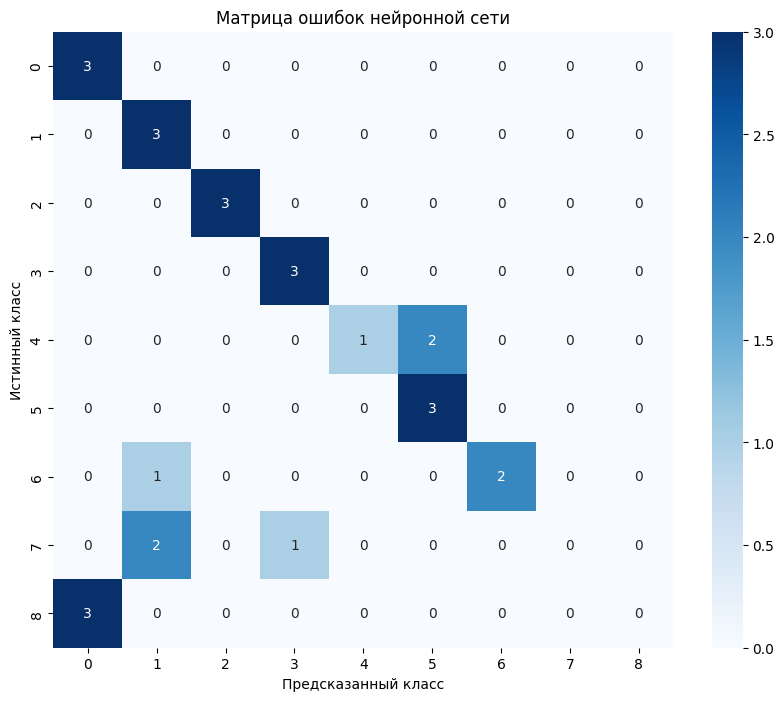

In [314]:
train_by_param(audio_df ,n_mfcc = 5, window='hamming', overlap_percentage=0.5)

Уникальные номера сегментов: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Всего сегментов: 15
Уникальные классы: ['distributivi', 'dokumenti', 'filmi', 'fotografii', 'igri', 'knigi', 'musika', 'proekti', 'zagruzki']
Класс distributivi: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 3, 4, 5, 7, 8, 9, 10, 12, 13, 14]
  Test сегменты: [6, 11, 15]
Класс dokumenti: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 3, 4, 6, 7, 9, 11, 12, 13, 14, 15]
  Test сегменты: [5, 8, 10]
Класс filmi: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 4, 5, 8, 9, 10, 11, 12, 13, 14, 15]
  Test сегменты: [3, 6, 7]
Класс fotografii: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 3, 5, 6, 8, 9, 10, 11, 12, 13, 14]
  Test сегменты: [4, 7, 15]
Класс igri: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 4, 5, 7, 8, 9, 

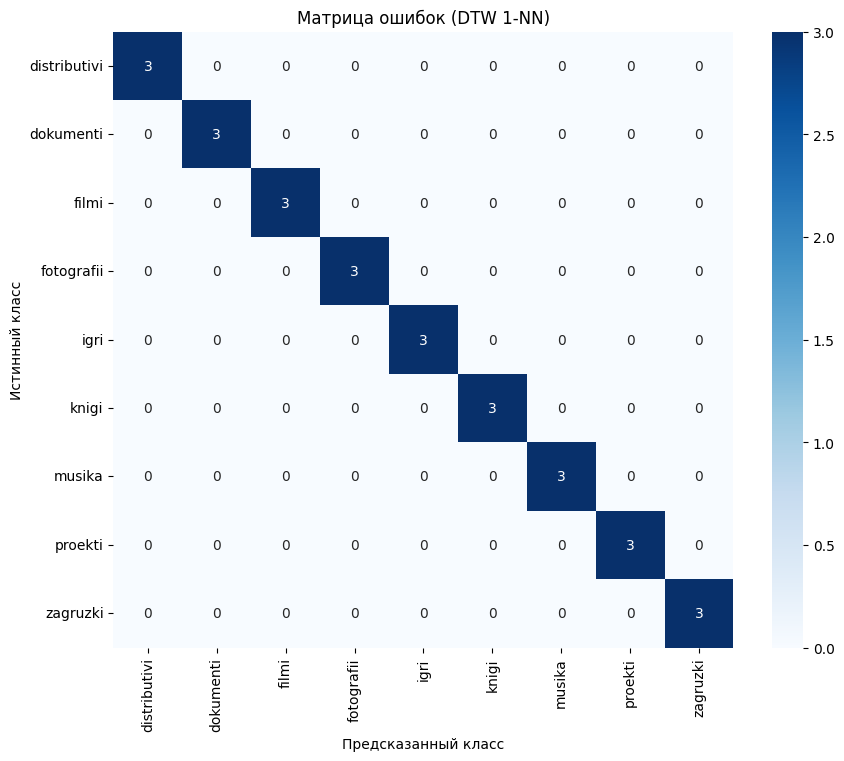

Epoch 1/15


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.1622 - loss: 2.2000 - val_accuracy: 0.0455 - val_loss: 2.2395
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2549 - loss: 2.0671 - val_accuracy: 0.0000e+00 - val_loss: 2.3087
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3300 - loss: 1.9731 - val_accuracy: 0.0000e+00 - val_loss: 2.3799
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4217 - loss: 1.8682 - val_accuracy: 0.0000e+00 - val_loss: 2.4561
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4338 - loss: 1.7491 - val_accuracy: 0.0000e+00 - val_loss: 2.5560
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4593 - loss: 1.6470 - val_accuracy: 0.0000e+00 - val_loss: 2.6624
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4948 - loss: 1.5276 - val_accuracy: 0.0000e+00 - val_loss: 2.7881
Epoch 8/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5521 - loss: 1.4036 - val_accuracy: 0.0000e+00 - val_los

c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

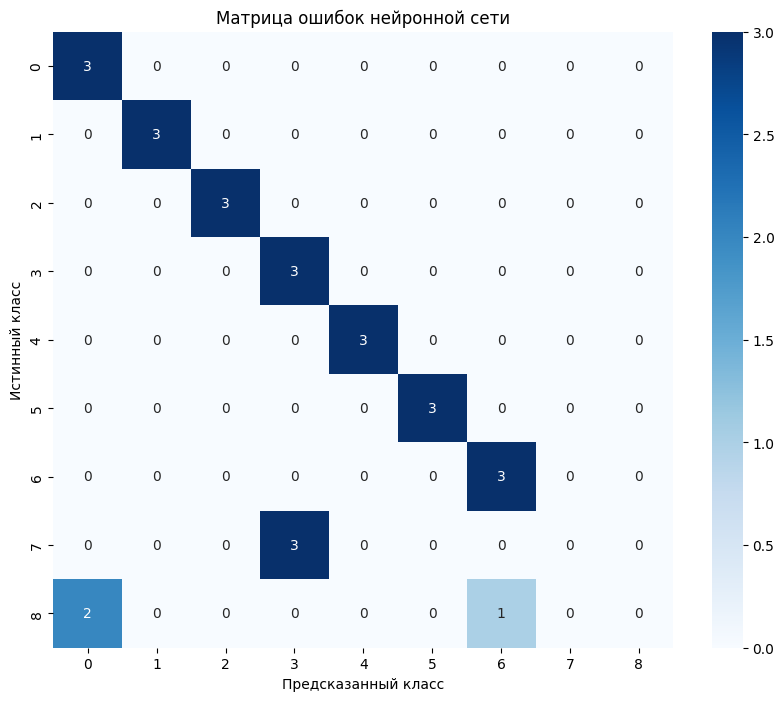

In [315]:
train_by_param(audio_df ,n_mfcc = 10, window='hamming', overlap_percentage=0.5)

Уникальные номера сегментов: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Всего сегментов: 15
Уникальные классы: ['distributivi', 'dokumenti', 'filmi', 'fotografii', 'igri', 'knigi', 'musika', 'proekti', 'zagruzki']
Класс distributivi: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 4, 5, 6, 7, 8, 10, 11, 12, 13, 15]
  Test сегменты: [3, 9, 14]
Класс dokumenti: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 15]
  Test сегменты: [9, 13, 14]
Класс filmi: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15]
  Test сегменты: [2, 3, 8]
Класс fotografii: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 3, 4, 6, 8, 9, 10, 11, 13, 14, 15]
  Test сегменты: [5, 7, 12]
Класс igri: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 3, 4, 6, 7, 8, 

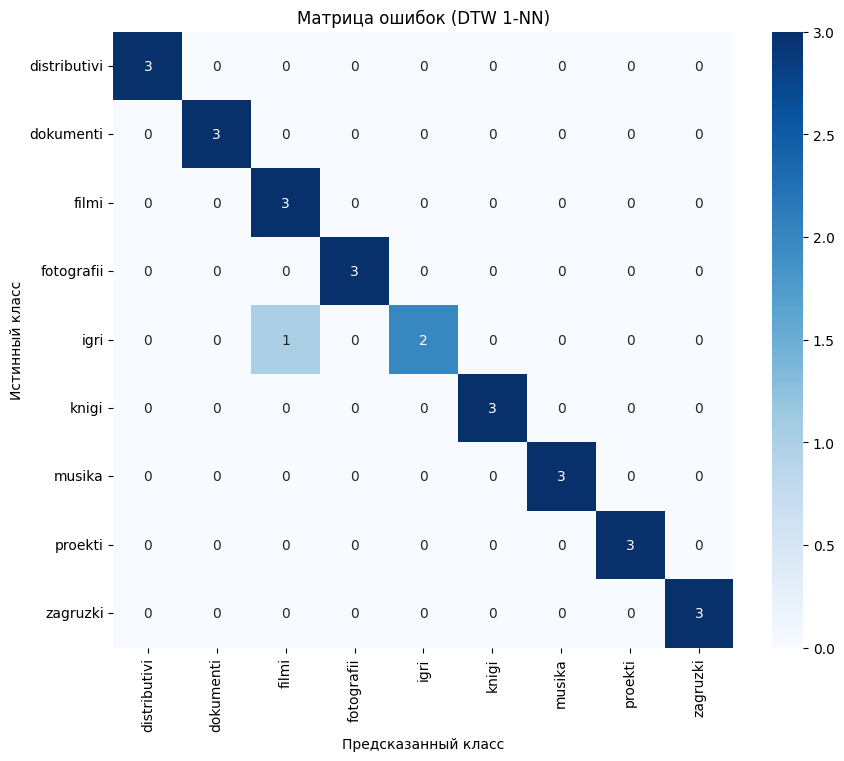

Epoch 1/15


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.1718 - loss: 2.3095 - val_accuracy: 0.1818 - val_loss: 2.0645
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3039 - loss: 2.1211 - val_accuracy: 0.1818 - val_loss: 2.1025
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5365 - loss: 1.9484 - val_accuracy: 0.1364 - val_loss: 2.1451
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4856 - loss: 1.8671 - val_accuracy: 0.0455 - val_loss: 2.2019
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5191 - loss: 1.7688 - val_accuracy: 0.0000e+00 - val_loss: 2.2569
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5381 - loss: 1.6117 - val_accuracy: 0.0000e+00 - val_loss: 2.2989
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6029 - loss: 1.4906 - val_accuracy: 0.0000e+00 - val_loss: 2.3818
Epoch 8/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6358 - loss: 1.3720 - val_accuracy: 0.0000e+00 - val_loss: 2.4922
E

c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

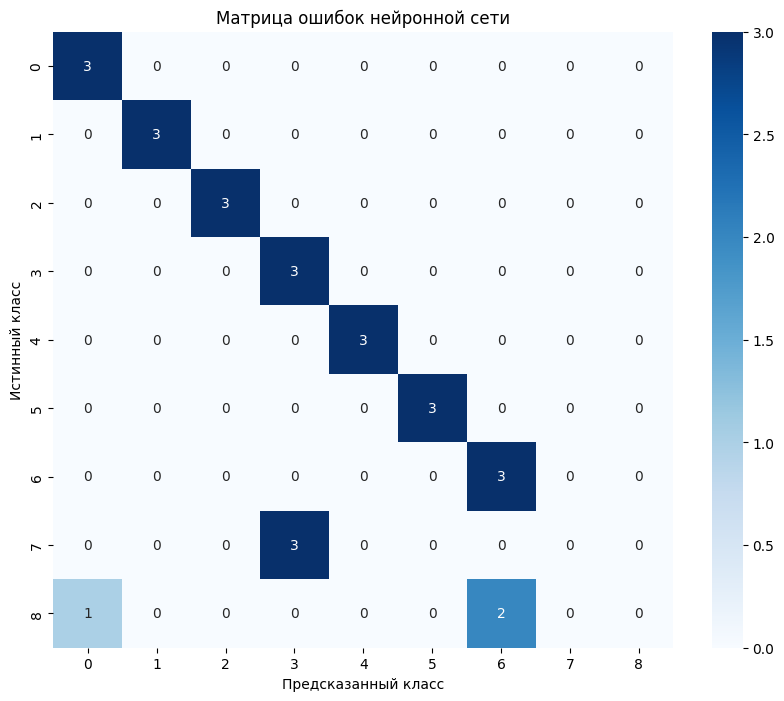

In [318]:
train_by_param(audio_df ,n_mfcc = 20, window='hamming', overlap_percentage=0.5)

Уникальные номера сегментов: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Всего сегментов: 15
Уникальные классы: ['distributivi', 'dokumenti', 'filmi', 'fotografii', 'igri', 'knigi', 'musika', 'proekti', 'zagruzki']
Класс distributivi: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 13, 14]
  Test сегменты: [11, 12, 15]
Класс dokumenti: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Test сегменты: [3, 4, 6]
Класс filmi: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 4, 5, 6, 7, 9, 10, 11, 12, 14, 15]
  Test сегменты: [3, 8, 13]
Класс fotografii: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 3, 4, 5, 6, 7, 8, 9, 12, 13, 14]
  Test сегменты: [10, 11, 15]
Класс igri: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 4, 5, 6, 8, 9, 

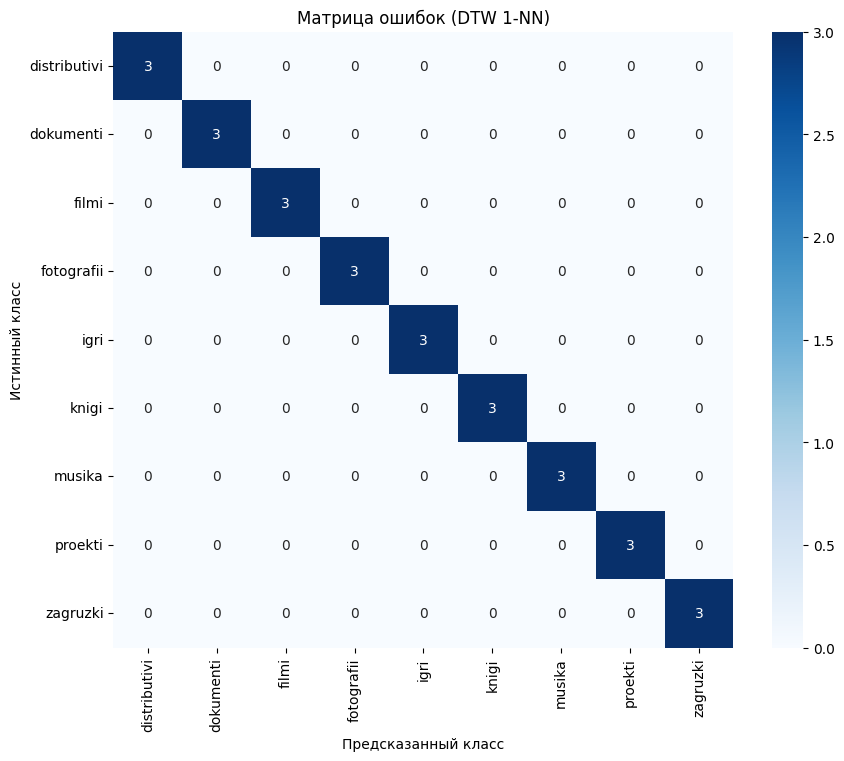

Epoch 1/15


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.1901 - loss: 2.1311 - val_accuracy: 0.0000e+00 - val_loss: 2.3963
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3509 - loss: 1.9418 - val_accuracy: 0.0000e+00 - val_loss: 2.4145
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4495 - loss: 1.7823 - val_accuracy: 0.0000e+00 - val_loss: 2.4630
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6264 - loss: 1.6146 - val_accuracy: 0.0000e+00 - val_loss: 2.5218
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6761 - loss: 1.4248 - val_accuracy: 0.0000e+00 - val_loss: 2.5647
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7642 - loss: 1.2154 - val_accuracy: 0.0000e+00 - val_loss: 2.6398
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7670 - loss: 1.0880 - val_accuracy: 0.0000e+00 - val_loss: 2.7366
Epoch 8/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7972 - loss: 0.8726 - val_accuracy: 0.0000e+00 - val

c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

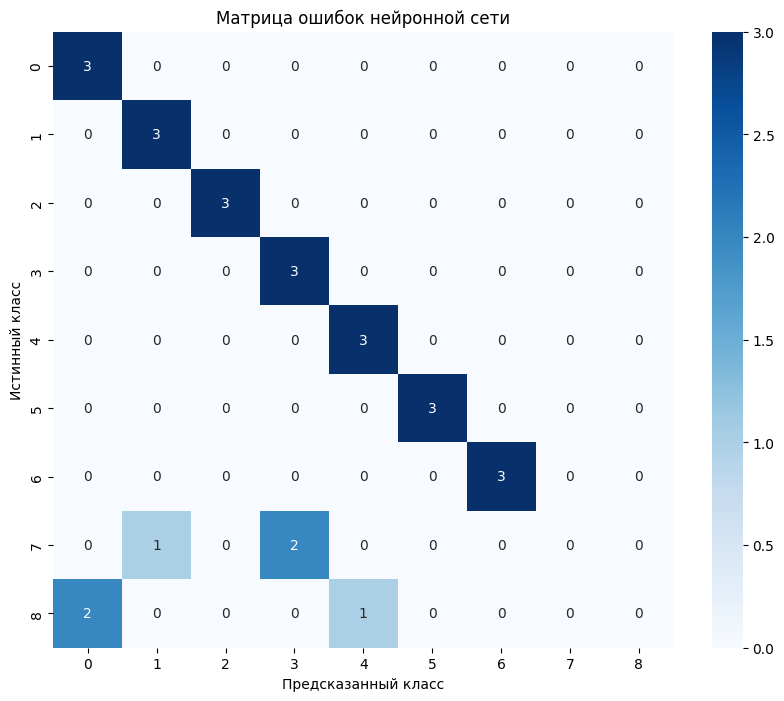

In [319]:
train_by_param(audio_df ,n_mfcc = 40, window='hamming', overlap_percentage=0.5)

<h3>По степени перекрытия</h3>

Уникальные номера сегментов: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Всего сегментов: 15
Уникальные классы: ['distributivi', 'dokumenti', 'filmi', 'fotografii', 'igri', 'knigi', 'musika', 'proekti', 'zagruzki']
Класс distributivi: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 3, 4, 5, 9, 10, 11, 12, 13, 14, 15]
  Test сегменты: [6, 7, 8]
Класс dokumenti: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
  Test сегменты: [2, 4, 15]
Класс filmi: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [2, 3, 4, 5, 6, 7, 9, 10, 12, 13, 14, 15]
  Test сегменты: [1, 8, 11]
Класс fotografii: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 3, 4, 5, 6, 8, 9, 12, 13, 14, 15]
  Test сегменты: [7, 10, 11]
Класс igri: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 3, 4, 5, 6, 8, 9, 

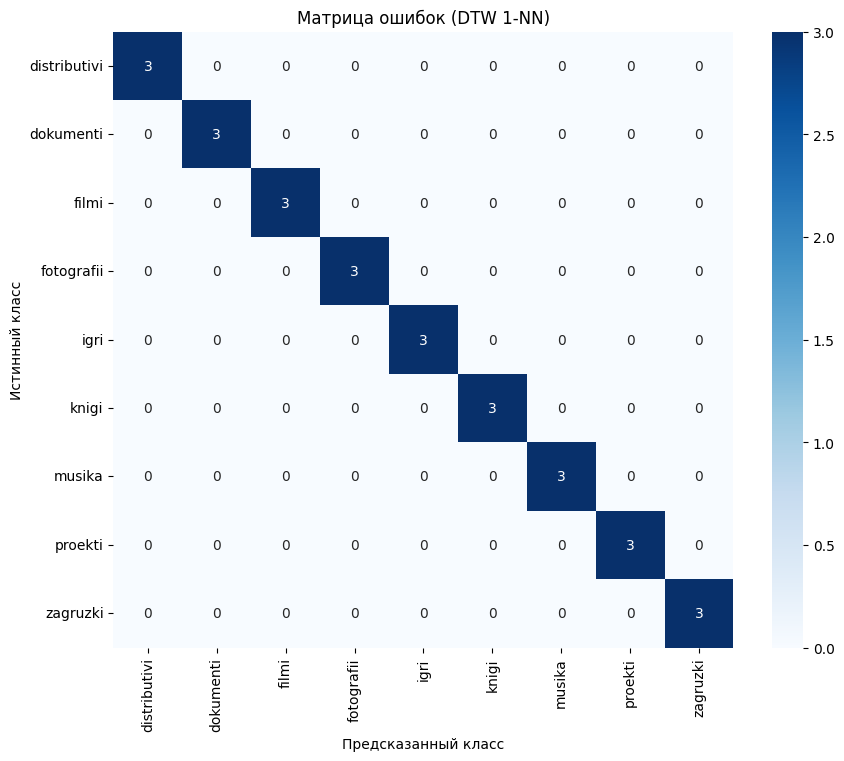

Epoch 1/15


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.1565 - loss: 2.0923 - val_accuracy: 0.0000e+00 - val_loss: 2.6301
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2721 - loss: 1.8910 - val_accuracy: 0.0000e+00 - val_loss: 2.7140
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3047 - loss: 1.7531 - val_accuracy: 0.0000e+00 - val_loss: 2.7883
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5094 - loss: 1.5234 - val_accuracy: 0.0000e+00 - val_loss: 2.8584
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5772 - loss: 1.4367 - val_accuracy: 0.0000e+00 - val_loss: 2.9336
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5762 - loss: 1.2614 - val_accuracy: 0.0000e+00 - val_loss: 3.0249
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6621 - loss: 1.2077 - val_accuracy: 0.0000e+00 - val_loss: 3.1075
Epoch 8/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7044 - loss: 1.0546 - val_accuracy: 0.0000e+00 - val

c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

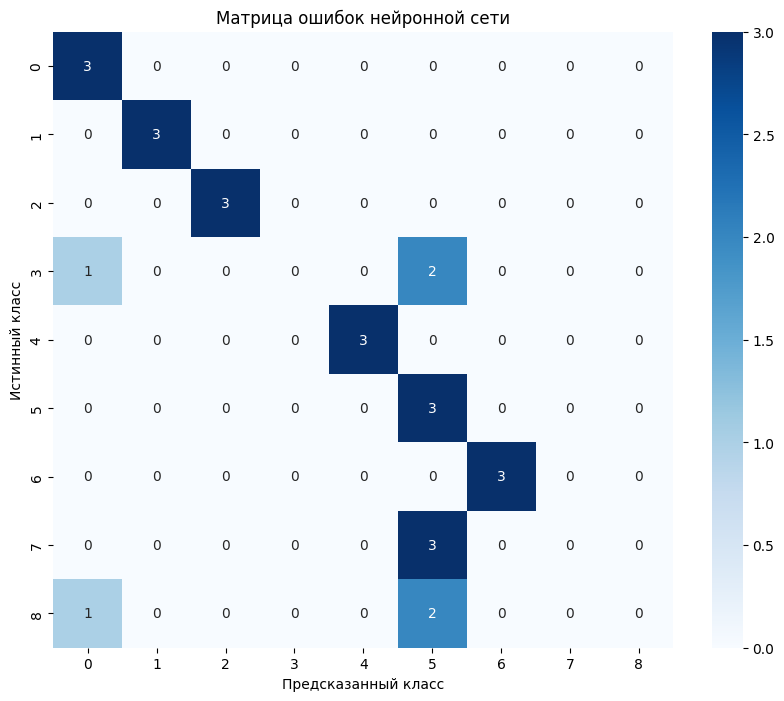

In [320]:
train_by_param(audio_df ,n_mfcc = 20, overlap_percentage=0.2, window='hamming')

Уникальные номера сегментов: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Всего сегментов: 15
Уникальные классы: ['distributivi', 'dokumenti', 'filmi', 'fotografii', 'igri', 'knigi', 'musika', 'proekti', 'zagruzki']
Класс distributivi: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 3, 4, 6, 8, 9, 10, 11, 12, 13, 14]
  Test сегменты: [5, 7, 15]
Класс dokumenti: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13]
  Test сегменты: [8, 14, 15]
Класс filmi: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [2, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15]
  Test сегменты: [1, 3, 7]
Класс fotografii: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 4, 5, 7, 8, 9, 10, 11, 13, 14, 15]
  Test сегменты: [3, 6, 12]
Класс igri: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 3, 4, 5, 8, 9, 

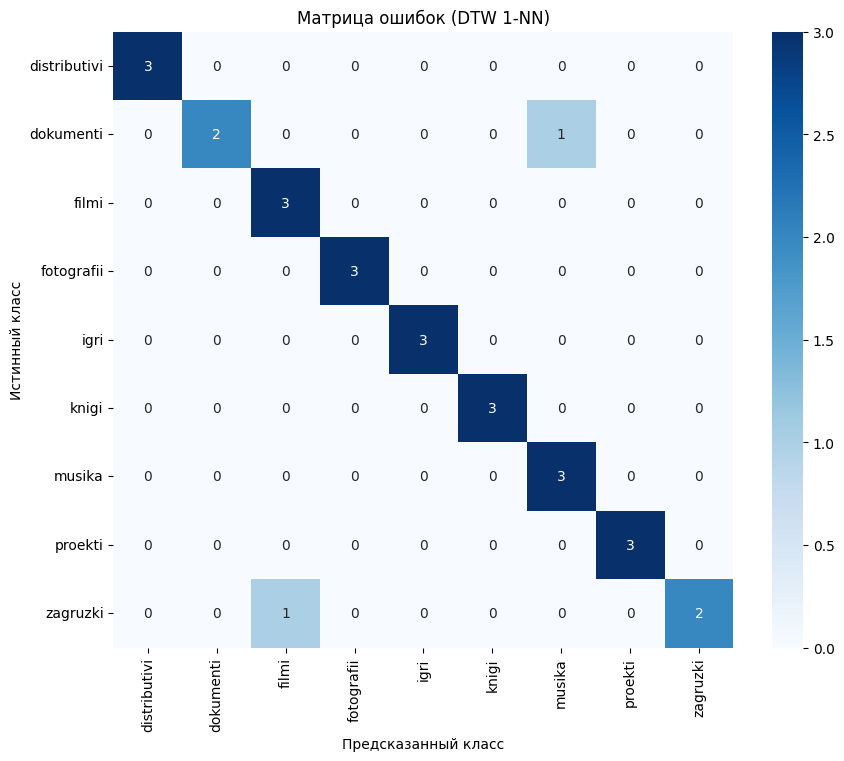

Epoch 1/15


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.1738 - loss: 2.2441 - val_accuracy: 0.0000e+00 - val_loss: 2.2156
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2825 - loss: 2.1214 - val_accuracy: 0.0000e+00 - val_loss: 2.2440
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3505 - loss: 1.9771 - val_accuracy: 0.0000e+00 - val_loss: 2.2776
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5752 - loss: 1.7858 - val_accuracy: 0.0000e+00 - val_loss: 2.2752
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6437 - loss: 1.6269 - val_accuracy: 0.0000e+00 - val_loss: 2.2786
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6607 - loss: 1.5942 - val_accuracy: 0.0000e+00 - val_loss: 2.2898
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7185 - loss: 1.4413 - val_accuracy: 0.0000e+00 - val_loss: 2.3261
Epoch 8/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7926 - loss: 1.3070 - val_accuracy: 0.0000e+00 - val

c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

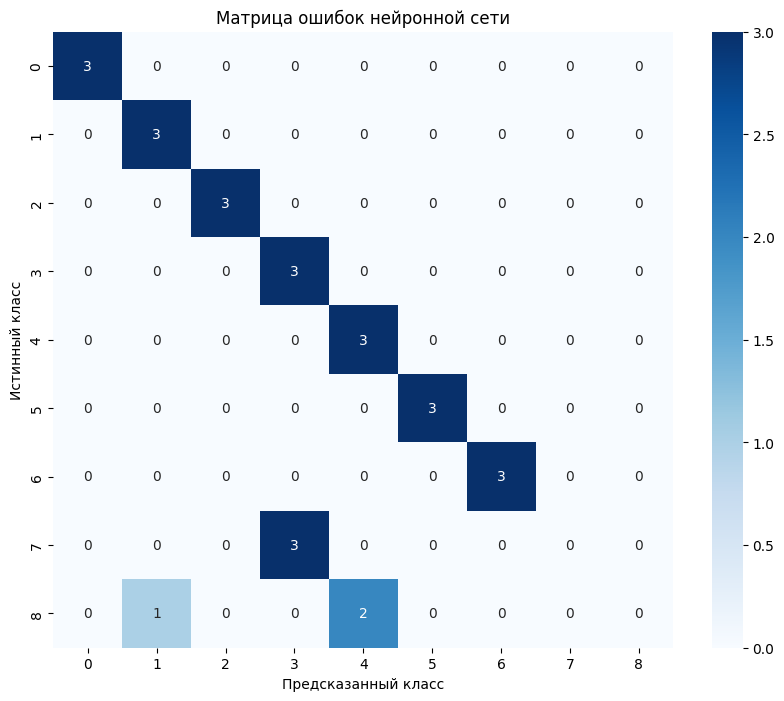

In [321]:
train_by_param(audio_df ,n_mfcc = 20, overlap_percentage=0.5, window='hamming')

Уникальные номера сегментов: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Всего сегментов: 15
Уникальные классы: ['distributivi', 'dokumenti', 'filmi', 'fotografii', 'igri', 'knigi', 'musika', 'proekti', 'zagruzki']
Класс distributivi: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 3, 4, 5, 6, 8, 10, 11, 12, 13, 15]
  Test сегменты: [7, 9, 14]
Класс dokumenti: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 4, 6, 8, 9, 10, 11, 12, 13, 14, 15]
  Test сегменты: [3, 5, 7]
Класс filmi: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 15]
  Test сегменты: [1, 12, 14]
Класс fotografii: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Test сегменты: [2, 3, 4]
Класс igri: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 3, 4, 5, 7, 9, 

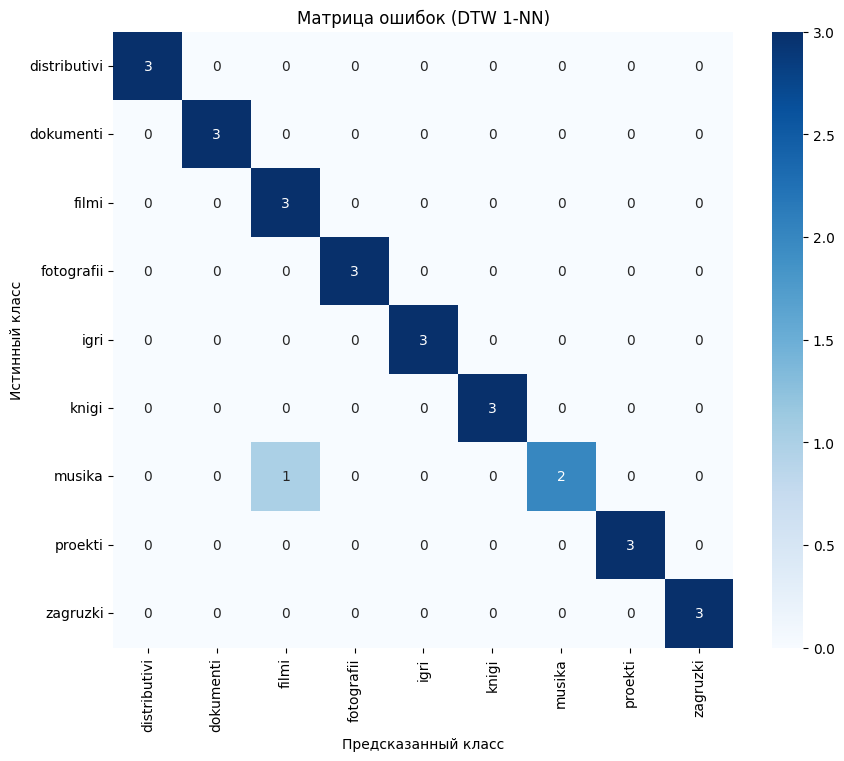

Epoch 1/15


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.0000e+00 - loss: 2.2613 - val_accuracy: 0.2727 - val_loss: 2.0232
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0573 - loss: 2.0684 - val_accuracy: 0.1818 - val_loss: 2.1098
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3416 - loss: 1.9145 - val_accuracy: 0.0455 - val_loss: 2.1555
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4828 - loss: 1.7760 - val_accuracy: 0.0455 - val_loss: 2.2056
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6029 - loss: 1.6446 - val_accuracy: 0.0455 - val_loss: 2.2438
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7866 - loss: 1.5189 - val_accuracy: 0.0000e+00 - val_loss: 2.2847
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8063 - loss: 1.3386 - val_accuracy: 0.0000e+00 - val_loss: 2.3171
Epoch 8/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8000 - loss: 1.2237 - val_accuracy: 0.0000e+00 - val_loss: 2.3720
Ep

c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

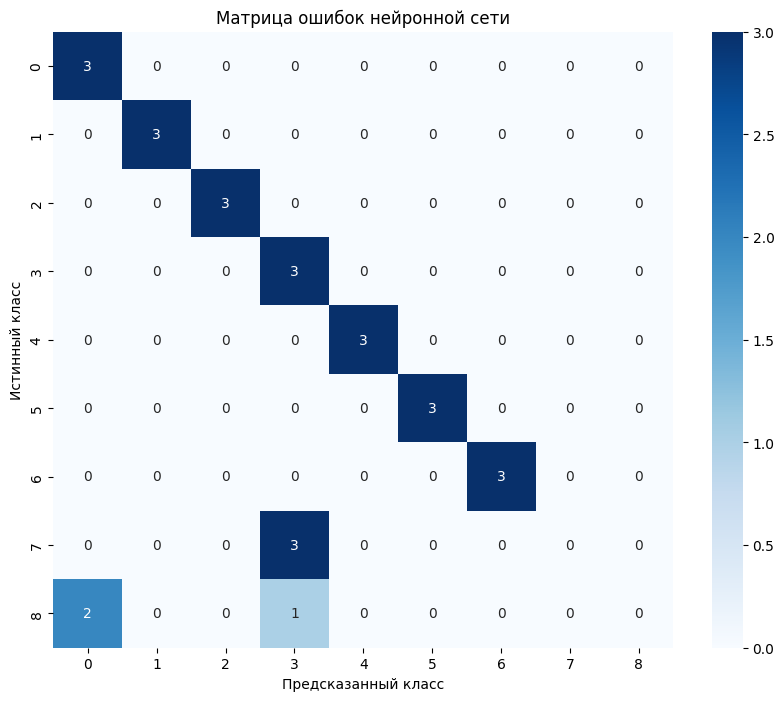

In [322]:
train_by_param(audio_df ,n_mfcc = 20, overlap_percentage=0.7, window='hamming')

<h3>Вид окна</h3>

Уникальные номера сегментов: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Всего сегментов: 15
Уникальные классы: ['distributivi', 'dokumenti', 'filmi', 'fotografii', 'igri', 'knigi', 'musika', 'proekti', 'zagruzki']
Класс distributivi: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 3, 4, 5, 6, 8, 10, 11, 12, 13, 14]
  Test сегменты: [7, 9, 15]
Класс dokumenti: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15]
  Test сегменты: [1, 3, 14]
Класс filmi: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 3, 4, 6, 7, 8, 9, 11, 12, 13, 14, 15]
  Test сегменты: [2, 5, 10]
Класс fotografii: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 3, 5, 7, 8, 9, 10, 11, 12, 13, 14]
  Test сегменты: [4, 6, 15]
Класс igri: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 4, 5, 6, 7, 9, 

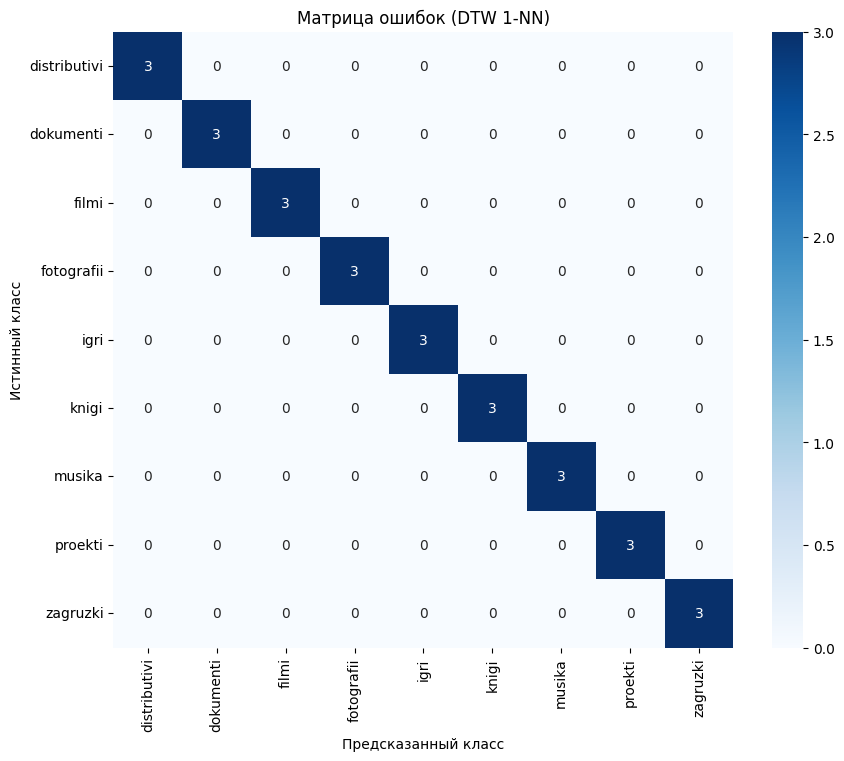

Epoch 1/15


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.1157 - loss: 2.3169 - val_accuracy: 0.0000e+00 - val_loss: 2.0283
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2689 - loss: 2.0767 - val_accuracy: 0.0000e+00 - val_loss: 2.0892
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4680 - loss: 1.8578 - val_accuracy: 0.0000e+00 - val_loss: 2.1439
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6863 - loss: 1.6500 - val_accuracy: 0.0000e+00 - val_loss: 2.1910
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7465 - loss: 1.4919 - val_accuracy: 0.0000e+00 - val_loss: 2.2329
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7830 - loss: 1.3143 - val_accuracy: 0.0000e+00 - val_loss: 2.2863
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8964 - loss: 1.1261 - val_accuracy: 0.0000e+00 - val_loss: 2.3556
Epoch 8/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8855 - loss: 0.9493 - val_accuracy: 0.0000e+00 - val

c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

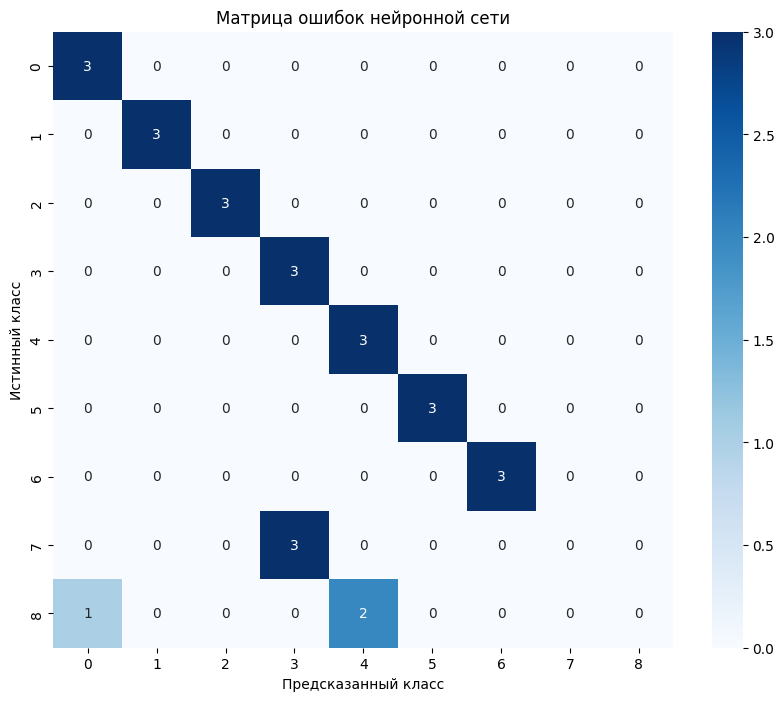

In [323]:
train_by_param(audio_df ,n_mfcc = 20, window='hamming', overlap_percentage=0.5)

Уникальные номера сегментов: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Всего сегментов: 15
Уникальные классы: ['distributivi', 'dokumenti', 'filmi', 'fotografii', 'igri', 'knigi', 'musika', 'proekti', 'zagruzki']
Класс distributivi: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 15]
  Test сегменты: [12, 13, 14]
Класс dokumenti: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 3, 4, 6, 7, 8, 10, 11, 12, 13, 14]
  Test сегменты: [5, 9, 15]
Класс filmi: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 3, 4, 5, 6, 7, 9, 10, 13, 14, 15]
  Test сегменты: [8, 11, 12]
Класс fotografii: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 14, 15]
  Test сегменты: [4, 12, 13]
Класс igri: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 3, 4, 5, 6, 7, 9, 

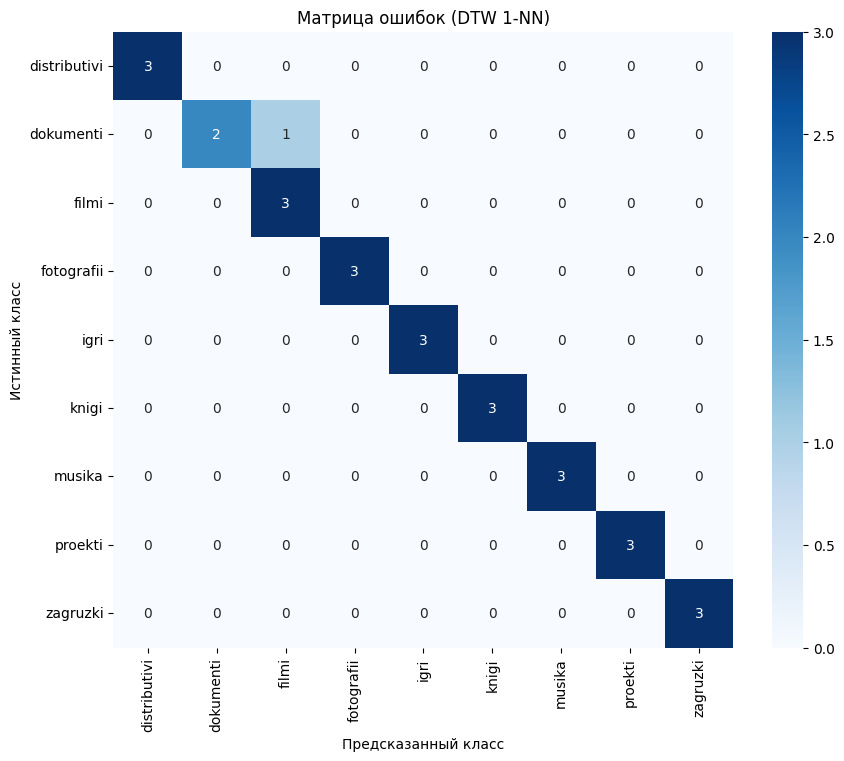

Epoch 1/15


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.0572 - loss: 2.4159 - val_accuracy: 0.0000e+00 - val_loss: 2.2947
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0889 - loss: 2.1899 - val_accuracy: 0.0000e+00 - val_loss: 2.3288
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2289 - loss: 2.0102 - val_accuracy: 0.0000e+00 - val_loss: 2.3681
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5181 - loss: 1.8789 - val_accuracy: 0.0000e+00 - val_loss: 2.3893
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5420 - loss: 1.7324 - val_accuracy: 0.0000e+00 - val_loss: 2.4308
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6951 - loss: 1.5682 - val_accuracy: 0.0000e+00 - val_loss: 2.4906
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8244 - loss: 1.3748 - val_accuracy: 0.0000e+00 - val_loss: 2.5669
Epoch 8/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8342 - loss: 1.1741 - val_accuracy: 0.0000e+00 - va

c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

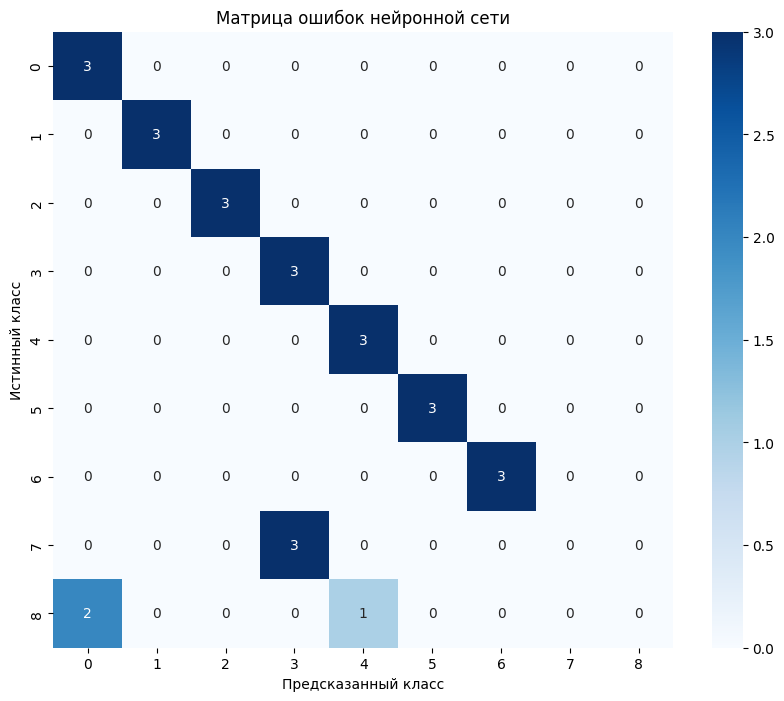

In [324]:
train_by_param(audio_df ,n_mfcc = 20, window='hann', overlap_percentage=0.5)

Уникальные номера сегментов: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Всего сегментов: 15
Уникальные классы: ['distributivi', 'dokumenti', 'filmi', 'fotografii', 'igri', 'knigi', 'musika', 'proekti', 'zagruzki']
Класс distributivi: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 3, 5, 6, 7, 8, 9, 10, 13, 14, 15]
  Test сегменты: [4, 11, 12]
Класс dokumenti: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 4, 6, 7, 8, 10, 11, 12, 13, 14, 15]
  Test сегменты: [3, 5, 9]
Класс filmi: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
  Test сегменты: [2, 4, 15]
Класс fotografii: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 3, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15]
  Test сегменты: [2, 4, 10]
Класс igri: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [2, 3, 5, 7, 8, 9, 10,

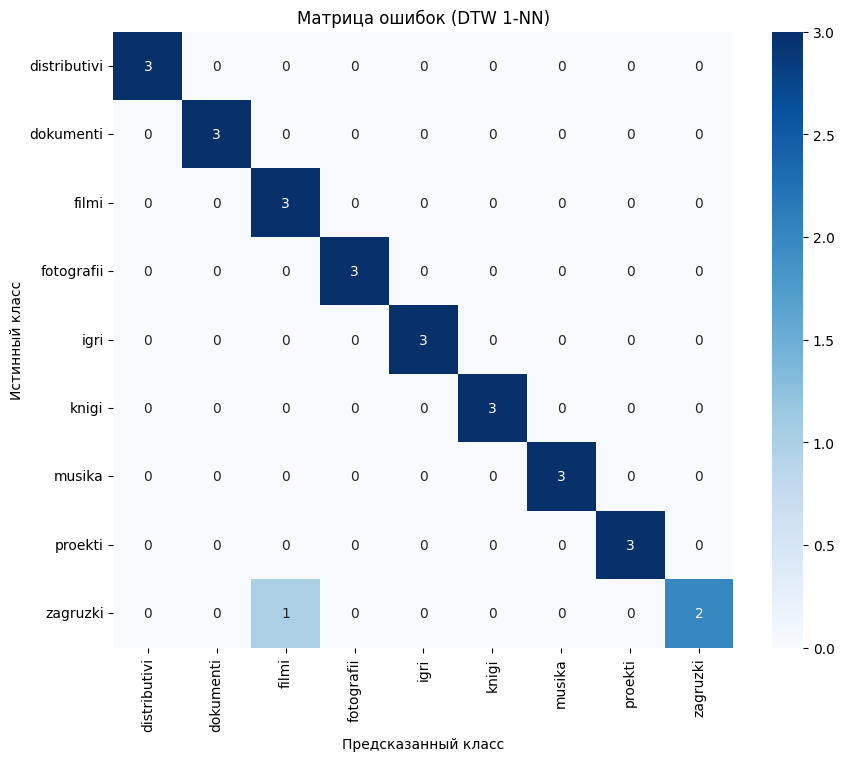

Epoch 1/15


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.1213 - loss: 2.2242 - val_accuracy: 0.0455 - val_loss: 2.1492
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3027 - loss: 2.0938 - val_accuracy: 0.0000e+00 - val_loss: 2.1533
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5338 - loss: 1.9311 - val_accuracy: 0.0000e+00 - val_loss: 2.1745
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5497 - loss: 1.8342 - val_accuracy: 0.0000e+00 - val_loss: 2.2108
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6056 - loss: 1.6863 - val_accuracy: 0.0000e+00 - val_loss: 2.2498
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6910 - loss: 1.5492 - val_accuracy: 0.0000e+00 - val_loss: 2.2917
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6958 - loss: 1.3876 - val_accuracy: 0.0000e+00 - val_loss: 2.3354
Epoch 8/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6424 - loss: 1.3661 - val_accuracy: 0.0000e+00 - val_los

c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

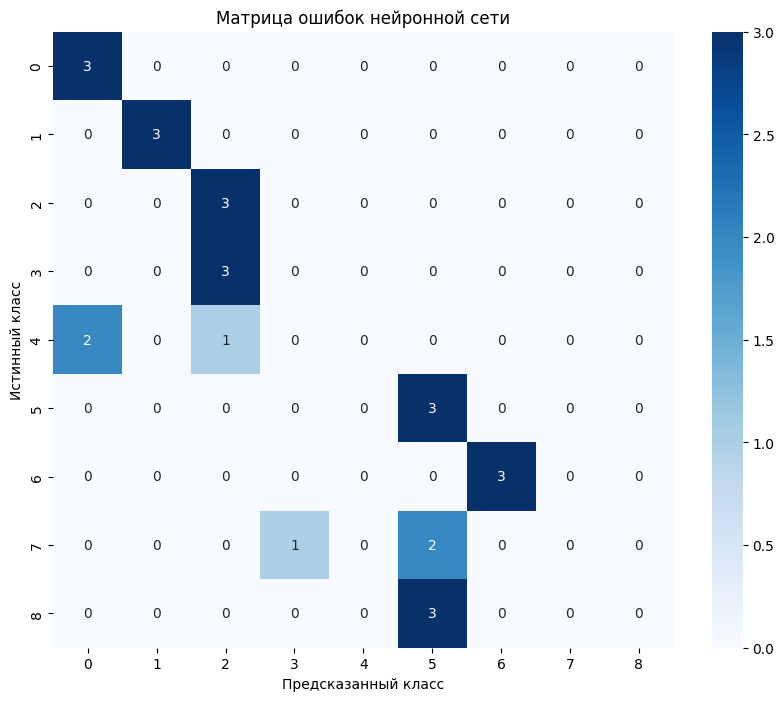

In [325]:
train_by_param(audio_df ,n_mfcc = 20, window='bartlett', overlap_percentage=0.5)